# Проект спринта 11. Модель для прогнозирования оттока клиентов для сервиса доставки кофе.
## Цель и задачи.
**Цель:** Определение клиентов, склонных к прекращению пользования сервисом доставки кофе на основании агрегированных параметров предыдущих заказов.

### Задачи:
1. Загрузка данных и знакомство с их содержимым.
2. Исследовательский анализ данных.
3. Предобработка данных для машинного обучения.
4. Разработка механизма предсказания оттока клиентов.
    - Обучение и оценка базовой модели.
    - Создание и отбор новых признаков.
    - Подбор гиперпараметров модели.
    - Финальное обучение модели и подготовка артефактов.
5. Формулировка выводов о качестве модели и повлиявших на него факторах.

### Постановка задачи в терминах машинного обучения
- Необходимо решить задачу машинного обучения для классификации клиентов на основе предоставленного датасета с признаками и значениями целевой переменной.
- Тип задачи машинного обучения: классификация.
- Целевая переменная - флаг, показывающий прогноз ухода клиента (да/нет), в терминах датасета - `churn`.
- Модель машинного обучения - логистическая регрессия.
- Необходимо минимизировать количество ложноположительных (FP) результатов.
- Основные метрики - F1, PR-AUC.
- Необходимо обеспечить воспроизводимость результатов при помощи указания фиксированного значения `random_state`.
- Для оценки модели должна применяться кросс-валидация.
- Для тестовой выборки необходимо выделить 20% измерений из датасета.
- Решение должно быть сохранено в виде готового к промышленной эксплуатации пайплайна.

## Данные

Для анализа поступили данные в формате CSV-файла, который доступен по ссылке [coffee_churn_dataset](https://code.s3.yandex.net/datasets/coffee_churn_dataset.csv).

- **Период агрегации.** Признаки агрегированы за последние 4 недели.
- **Формат данных.** Они представлены в виде готовой аналитической витрины. Это означает, что для каждого клиента уже рассчитаны и собраны в одну строку все необходимые для моделирования признаки.
- **Структура.** Каждая строка — это один уникальный клиент. Все признаки уже вычислены и представлены в виде числовых и категориальных значений.

#### **Признаки в датасете**

- `user_id` — идентификатор пользователя.
- `days_since_last_order` — количество дней, прошедших с последнего заказа.
- `order_frequency_month` — среднее число заказов в месяц.
- `order_frequency_week` — среднее число заказов в неделю.
- `avg_order_value` — средний чек, в рублях.
- `median_order_value` — медианный чек, в рублях.
- `total_spent_last_month` — сумма заказов за последний месяц.
- `total_spent_last_week` — сумма заказов за последнюю неделю.
- `discount_usage_rate` — доля заказов со скидкой за последний месяц.
- `last_coffee_type` — сорт кофе, купленный пользователем в последний раз на момент сбора данных.
- `preferred_roast` — предпочитаемый тип обжарки.
- `milk_preference` — предпочитаемый тип молока.
- `seasonal_menu_tried` — отметка о том, пробовал ли пользователь новейшее сезонное меню.
- `coffee_bean_origin` — страна происхождения зерна.
- `last_drink_size` — размер последнего заказа, совершённого на момент сбора данных.
- `subscription_status` — тип подписки пользователя.
- `app_opens_per_week` — сколько раз за неделю пользователь в среднем открывал приложение доставки кофе.
- `notifications_enabled` — включены ли у пользователя уведомления.
- `review_rating_last_10` — средняя оценка последних на момент сбора данных десяти заказов клиента.
- `review_rating_last_1` — оценка последнего на момент сбора данных заказа клиента.
- `app_crashes_last_month` — сколько раз приложение зависало за последний месяц.
- `seasons` — текущее время года.
- `days_since_last_promo` — сколько дней прошло с последнего использования акции или промокода.
- `phone_type` — тип устройства, с которого пользователь чаще всего совершал покупки.
- `coffee_preference_change` — менялись ли вкусовые предпочтения пользователя.
- `geo_id` — идентификатор региона пользователя.
- `churn` — перестал ли пользователь пользоваться сервисом.

## Структура проекта
- [Этап 1. Подготовка среды и библиотек.](#этап-1-подготовка-среды-и-библиотек)
- [Этап 2. Первичный анализ данных.](#этап-2-первичный-анализ-данных)
- [Этап 3. Предобработка данных.](#этап-3-предобработка-данных)
- [Этап 4. Обучение модели.](#этап-4-обучение-модели)
- [Этап 5. Создание новых признаков.](#этап-5-создание-новых-признаков)
- [Этап 6. Эксперименты с гиперпараметрами.](#этап-6-эксперименты-с-гиперпараметрами)
- [Этап 7. Подготовка финальной модели.](#этап-7-подготовка-финальной-модели)
- [Этап 8. Отчет о проделанной работе.](#этап-8-отчёт-о-проделанной-работе)
- [Этап 9. Сохранение модели для продакшена.](#этап-9-сохранение-модели-для-продакшена)

## Этап 1. Подготовка среды и библиотек

- Установим библиотеки и импортируем пакеты:

In [ ]:
%pip install -q numpy==1.23
%pip install -q --upgrade scikit-learn
%pip install -q --upgrade seaborn
%pip install -q --upgrade jinja2
%pip install -q phik

# Сохраним версии библиотек в requirements.txt
%pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import math

import pandas as pd
import numpy as np
import phik

# Библиотеки машинного обучения
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, TargetEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, f1_score, \
    average_precision_score, precision_recall_curve, log_loss, recall_score, precision_score
from sklearn.model_selection import cross_validate, KFold, StratifiedKFold
from sklearn.dummy import DummyClassifier

# Библиотеки для построения графиков
import seaborn as sns
import matplotlib.pyplot as plt

# Сериализация пайплайна
import joblib

# Для форматирования в HTML
from IPython.display import display, HTML, Markdown

- Зафиксируем `random_state` для воспроизводимости результатов:

In [3]:
RANDOM_STATE = 627

## Этап 2. Первичный анализ данных

- Загрузим данные в формате CSV и выведем сведения о них:

In [4]:
try:
    # Сначала загрузим данныз из локального файла
    df = pd.read_csv("datasets/coffee_churn_dataset.csv", sep=",", decimal=".")
except FileNotFoundError:
    # Если файла нет, загружаем по сети
    df = pd.read_csv("https://code.s3.yandex.net/datasets/coffee_churn_dataset.csv", sep=",", decimal=".")
display(df.info())
display(df.head(10))

initial_count = len(df)

# Посчитаем количество явных дубликатов
dup_columns = df.columns.to_list()
dup_columns.remove('user_id')
dup_count = df[dup_columns].duplicated().sum()
print(f"Количество дубликатов: {dup_count} ({dup_count / initial_count * 100: .2f}%)")

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   str    
 14  last_drink_size  

None

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1
5,user_01247,0.0,1.284824,0.418197,1092.164843,338.082043,471.825472,159.366225,0.350490,arabica,...,0.0,4.235214,4.835587,1.0,winter,17.0,android,0.0,geo_68,0
6,user_08887,5.0,6.124180,1.214905,428.486273,174.449445,1088.359993,254.120345,0.146130,robusta,...,NaN,4.406612,4.144391,0.0,spring,9.0,android,0.0,geo_3,0
7,user_01885,3.0,4.640247,1.029297,27.368788,9.812365,NaN,10.523663,0.173646,robusta,...,1.0,4.793547,4.321319,3.0,NaN,12.0,android,0.0,geo_3,1
8,user_03703,9.0,3.303446,NaN,1886.543949,964.629212,3312.557597,748.655191,0.676576,blend,...,1.0,4.405572,NaN,0.0,spring,5.0,android,0.0,geo_45,0
9,user_01536,0.0,0.310724,-0.094052,607.847810,NaN,151.508968,-41.895977,NaN,blend,...,1.0,4.362385,2.624536,2.0,autumn,14.0,ios,0.0,geo_2,0


Количество дубликатов: 414 ( 3.96%)


- Удалим дубликаты и отобразим сведения о получившемся датасете:

In [5]:
df = df.drop_duplicates(subset=dup_columns)
df.info()

misses_count = df.isna().any(axis=1).sum()
print(f"\nКоличество строк с пропусками: {misses_count} ({misses_count / len(df) * 100:.2f}%)")

<class 'pandas.DataFrame'>
Index: 10036 entries, 0 to 10448
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10036 non-null  str    
 1   days_since_last_order     9134 non-null   float64
 2   order_frequency_month     9454 non-null   float64
 3   order_frequency_week      9659 non-null   float64
 4   avg_order_value           9476 non-null   float64
 5   median_order_value        9232 non-null   float64
 6   total_spent_last_month    9748 non-null   float64
 7   total_spent_last_week     9120 non-null   float64
 8   discount_usage_rate       9653 non-null   float64
 9   last_coffee_type          9786 non-null   str    
 10  preferred_roast           9925 non-null   str    
 11  milk_preference           9395 non-null   str    
 12  seasonal_menu_tried       9086 non-null   float64
 13  coffee_bean_origin        9394 non-null   str    
 14  last_drink_size       

- 78.2% строк датасета имеют пропуск хотя бы в одном признаке.
- Пропуски распределены между признаками примерно поровну, поэтому удаление строк или столбцов не является подходящим решением. Необходимо заполнять пропуски статистиками или значением-индикатором.
- Целевой переменной является флаг ухода пользователя (столбец `churn`). Этот столбец не содержит пропусков. Проверим баланс положительного и отрицательного классов:

In [6]:
churn_positive_count = df['churn'].sum()
print(f"Количество записей в положительном классе: {churn_positive_count} ({churn_positive_count / len(df) * 100:.2f}%)")

Количество записей в положительном классе: 602 (6.00%)


Классы несбалансированы: соотношение положительного и отрицательного классов: 6% против 94%.

- Выведем количество категорий в категориальных и дискретных столбцах:

In [7]:
cat_columns = ['last_coffee_type', 
               'preferred_roast',
               'milk_preference',
               'coffee_bean_origin',
               'last_drink_size',
               'subscription_status',
               'seasons',
               'phone_type',
               'geo_location',
               'app_crashes_last_month']

pd.DataFrame(df[cat_columns].nunique().sort_values(ascending=False)).style.background_gradient(cmap='viridis')

,0
geo_location,100
app_crashes_last_month,8
milk_preference,6
coffee_bean_origin,6
seasons,4
subscription_status,4
preferred_roast,3
last_coffee_type,3
last_drink_size,3
phone_type,3


In [8]:
# Функция для построения скаттерплота в сетке
def draw_scatterplot_grid(data, 
                     title, 
                     x, 
                     y, 
                     hue,
                     xlabel, 
                     ylabel,
                     ax):
    sns.scatterplot(data=data, 
                    x=x,
                    y=y,
                    hue=hue, 
                    ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

# Функция для построения боксплота в сетке
def draw_boxplot_grid(data,
                    field,
                    title, 
                    xlabel, 
                    ylabel, 
                    **kwargs):
    sns.boxplot(data=data,
                x=field,   
                showmeans=True,
                legend=False,
                meanprops={
                    "marker": "o",
                    "markerfacecolor": "white",
                    "markeredgecolor": "black",
                    "markersize": 8
                },
                orient='h',
                **kwargs)
    kwargs['ax'].set_title(title)
    kwargs['ax'].set_xlabel(xlabel)
    kwargs['ax'].set_ylabel(ylabel)

# Функция для построения гистограммы в сетке
def draw_histogram_grid(data,
                        field,
                        title,
                        xlabel, 
                        ylabel,
                        **kwargs):
    sns.histplot(data=data,
                x=field,
                 **kwargs)

    # plt.xticks(np.arange(0, 1300, step=50), rotation=90)
    kwargs['ax'].set_title(title)
    kwargs['ax'].set_xlabel(xlabel)
    kwargs['ax'].set_ylabel(ylabel)

# Функция для построения столбчатой диаграммы в сетке
def draw_barplot_grid(series, 
                 title, 
                 xlabel, 
                 ylabel, 
                 rot, 
                 vertical, 
                 mean,
                 ax):
    series.head(20).plot(
        title=title,
        kind='bar' if vertical else 'barh',
        xlabel=xlabel if vertical else ylabel,
        ylabel=ylabel if vertical else xlabel,
        grid=True,
        rot=rot,
        ax=ax)
    
    if mean != None:
        if vertical:
            ax.axhline(mean, color='red', linestyle='--')
        else:
            ax.axvline(mean, color='red', linestyle='--')    

# Функция для построения тепловой карты
def draw_heatmap(df, title, figsize=(12,12)):
    plt.figure(figsize=figsize)
    plt.title(title)
    sns.heatmap(data=df, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()    

# Функция для построения гистограммы и боксплота на одной шкале
def draw_double_diag(data, title, x, hue, xlabel, ylabel, stat='count', figsize=(12, 6), bins='auto', kde=True):
    fig, (ax_hist, ax_box) = plt.subplots(
        nrows=2,
        ncols=1,
        sharex=True,
        figsize=figsize,
        gridspec_kw={'height_ratios': [2, 1]}
    )

    sns.boxplot(data=data,
                ax=ax_box,
                x=x, 
                hue=hue, 
                showmeans=True,
                legend=False,
                meanprops={
                    "marker": "o",
                    "markerfacecolor": "white",
                    "markeredgecolor": "black",
                    "markersize": 8
                })

    ax_box.set_xlabel('')  # Убираем подпись оси X, чтобы не дублировалась
    ax_box.set_ylabel('')  # Убираем подпись оси Y
    ax_box.set_yticks([])  # Убираем тики оси Y (они не нужны)

    sns.histplot(data=data,
                ax=ax_hist,
                x=x,
                hue=hue,
                kde=kde,
                bins=bins,
                stat=stat)

    ax_hist.set_xlabel(xlabel)
    ax_hist.set_ylabel(ylabel)

    fig.suptitle(title, fontsize=14)

    plt.tight_layout()
    plt.show()

- Выведем столбчатые диаграммы для категориальных и дискретных признаков:

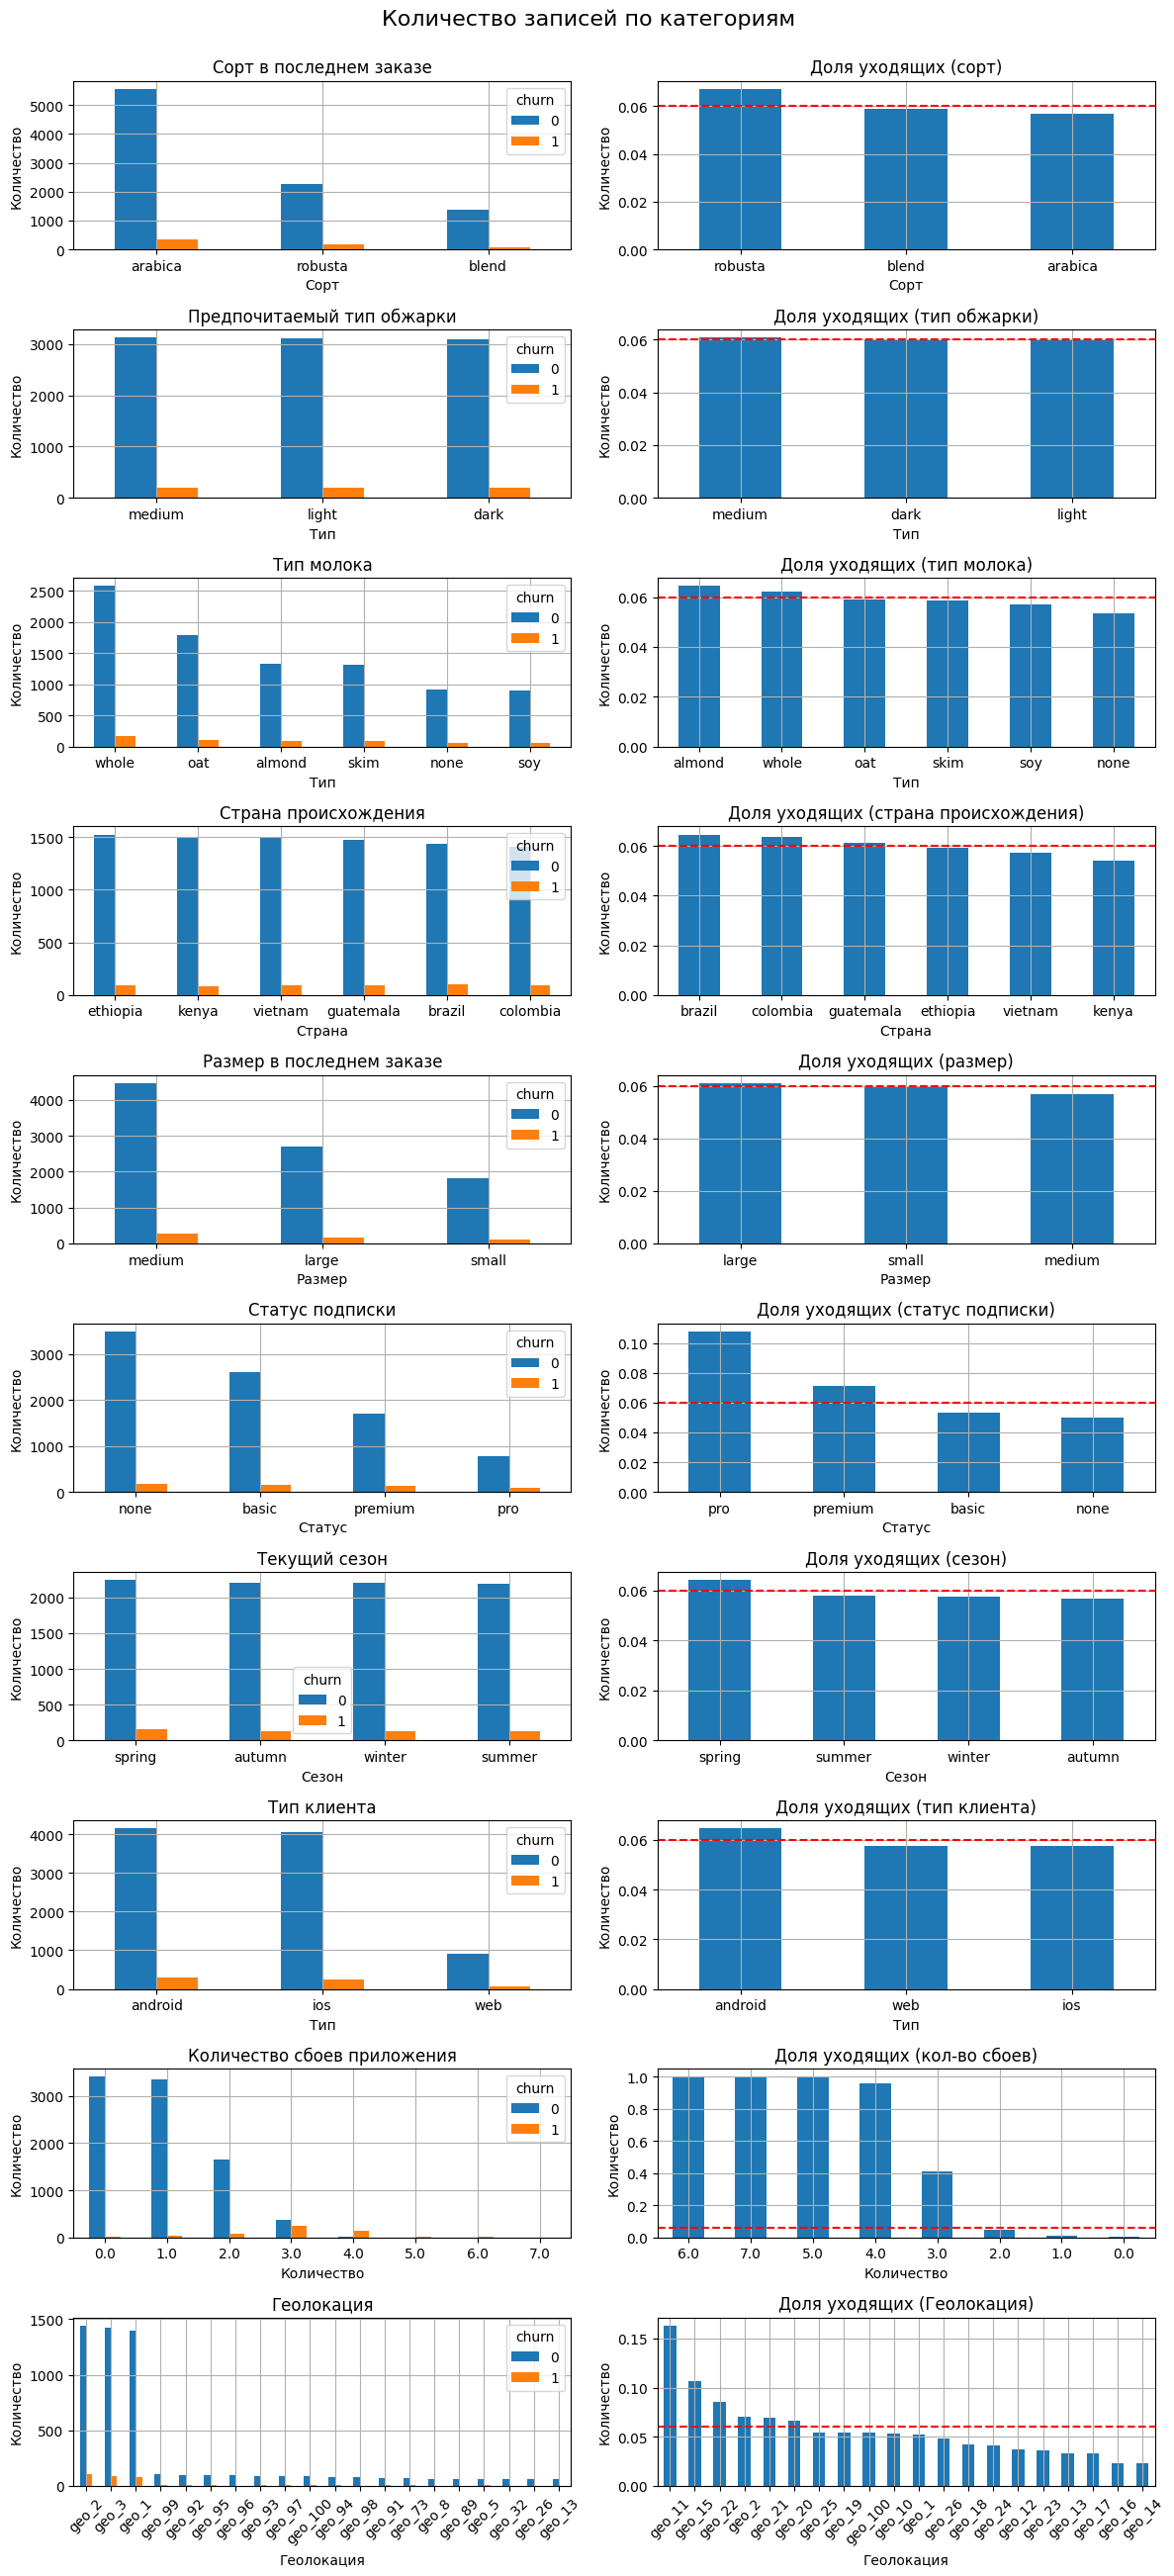

In [9]:
def get_data_for_barplot(df, column):
    return (df
            .groupby(by=column)['churn']
            .value_counts()
            .unstack(fill_value=0)
            .sort_values(by=0, ascending=False))

def get_churn_ratios(df, column):
    rv = (df
        .groupby(by=column)['churn']
        .mean()
        .head(20))
    return rv.sort_values(ascending=False)

mean_churn_ratio = df['churn'].mean()

graph_data = [[get_data_for_barplot(df, 'last_coffee_type'), "Сорт в последнем заказе", "Сорт", "Количество", 0, True, None],
              [get_churn_ratios(df, 'last_coffee_type'), "Доля уходящих (сорт)", "Сорт", "Количество", 0, True, mean_churn_ratio],
              [get_data_for_barplot(df, 'preferred_roast'), "Предпочитаемый тип обжарки", "Тип", "Количество", 0, True, None],
              [get_churn_ratios(df, 'preferred_roast'), "Доля уходящих (тип обжарки)", "Тип", "Количество", 0, True, mean_churn_ratio],
              [get_data_for_barplot(df, 'milk_preference'), "Тип молока", "Тип", "Количество", 0, True, None],
              [get_churn_ratios(df, 'milk_preference'), "Доля уходящих (тип молока)", "Тип", "Количество", 0, True, mean_churn_ratio],
              [get_data_for_barplot(df, 'coffee_bean_origin'), "Страна происхождения", "Страна", "Количество", 0, True, None],
              [get_churn_ratios(df, 'coffee_bean_origin'), "Доля уходящих (страна происхождения)", "Страна", "Количество", 0, True, mean_churn_ratio],
              [get_data_for_barplot(df, 'last_drink_size'), "Размер в последнем заказе", "Размер", "Количество", 0, True, None],
              [get_churn_ratios(df, 'last_drink_size'), "Доля уходящих (размер)", "Размер", "Количество", 0, True, mean_churn_ratio],
              [get_data_for_barplot(df, 'subscription_status'), "Статус подписки", "Статус", "Количество", 0, True, None],
              [get_churn_ratios(df, 'subscription_status'), "Доля уходящих (статус подписки)", "Статус", "Количество", 0, True, mean_churn_ratio],
              [get_data_for_barplot(df, 'seasons'), "Текущий сезон", "Сезон", "Количество", 0, True, None],
              [get_churn_ratios(df, 'seasons'), "Доля уходящих (сезон)", "Сезон", "Количество", 0, True, mean_churn_ratio],
              [get_data_for_barplot(df, 'phone_type'), "Тип клиента", "Тип", "Количество", 0, True, None],
              [get_churn_ratios(df, 'phone_type'), "Доля уходящих (тип клиента)", "Тип", "Количество", 0, True, mean_churn_ratio],
              [get_data_for_barplot(df, 'app_crashes_last_month'), "Количество сбоев приложения", "Количество", "Количество", 0, True, None],
              [get_churn_ratios(df, 'app_crashes_last_month'), "Доля уходящих (кол-во сбоев)", "Количество", "Количество", 0, True, mean_churn_ratio],
              [get_data_for_barplot(df, 'geo_location'), "Геолокация", "Геолокация", "Количество", 45, True, None],
              [get_churn_ratios(df, 'geo_location'), "Доля уходящих (Геолокация)", "Геолокация", "Количество", 45, True, mean_churn_ratio]]

fig, axes = plt.subplots(10, 2, figsize=(12, 26))

for ax, kwargs in zip(axes.flatten(), graph_data):
    draw_barplot_grid(*kwargs + [ax])

plt.suptitle("Количество записей по категориям", fontsize=16, y=1)
plt.tight_layout()
plt.show()

- Доля уходящих пользователей в наибольшей степени связана со статусом подписки. Чаще всего уходят пользователи с подписками pro и premium. Вероятно, это связано с недостаточно высоким качеством кофе премиальных категорий или с отсутствием выгодных предложений для этой категории.
- Есть связь доли уходящих пользователей с типом приложения (пользователи на Android уходят чаще), сортом (заказавшие сорт robusta в последнем заказе), слабее связь с типом молока (almond и whole) и страной происхождения (Бразилия, Колумбия и Гватемала). Также чаще клиенты уходят весной.
- Зависимость ухода клиента от количества сбоев приложения очень высока - уходят практически все клиенты, у которых за месяц было 4 и более сбоев. Можно предположить, что одна из причин ухода - низкое качество приложения на Android.
- Наибольшее количество категориальных значений - у геолокации. 6 регионов показывают долю уходов выше среднего.
- Связь доли уходов с типом обжарки отсутствует - этот признак можно удалить.
- Признаки с небольщим количество значений могут быть закодированы с использованием метода One-hot Encoding. Это относится к признакам `subscription_status`, `last_coffee_type`, `phone_type`, `seasons`, `milk_preference`.
- Признак `geo_location` содержит большое количество значений, поэтому его следует закодировать при помощи Tagret Encoding.

- Выведем диаграммы распределения для числовых признаков:

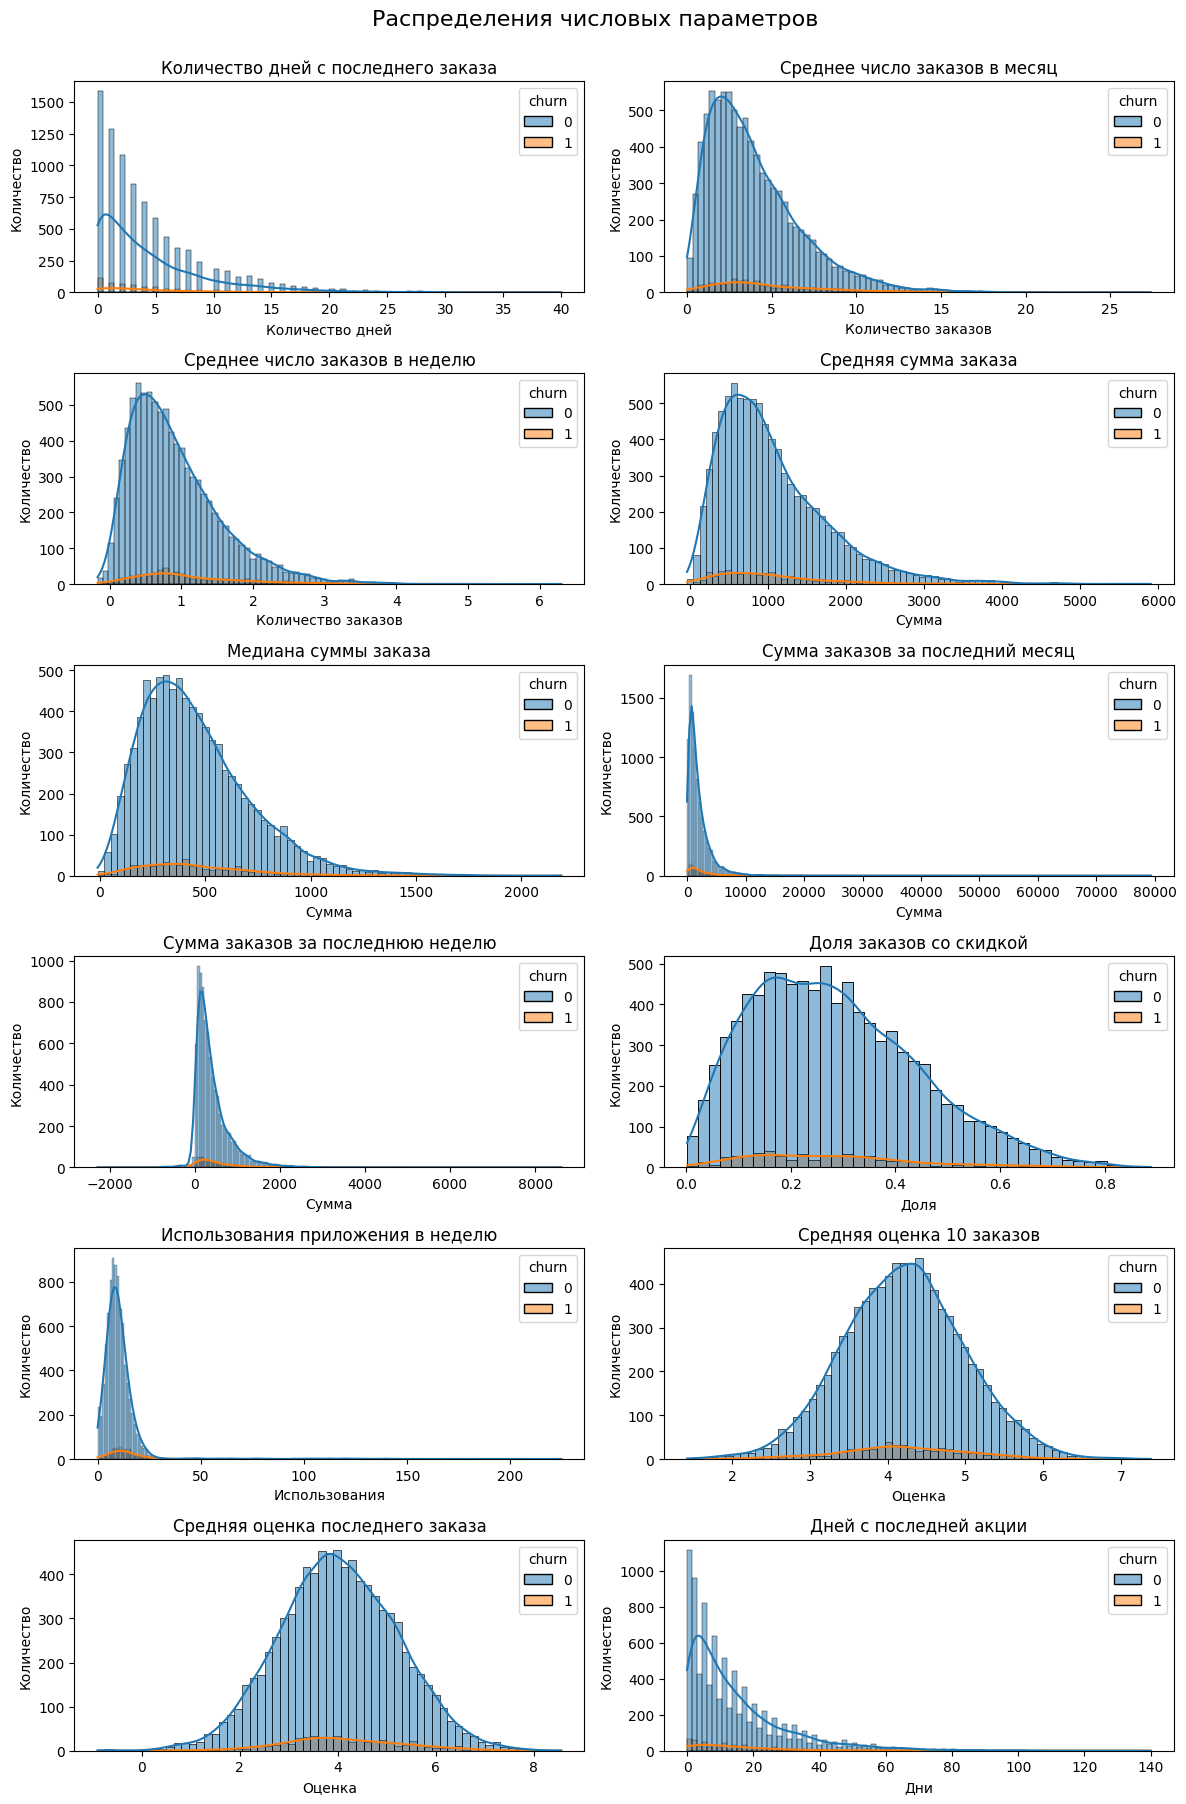

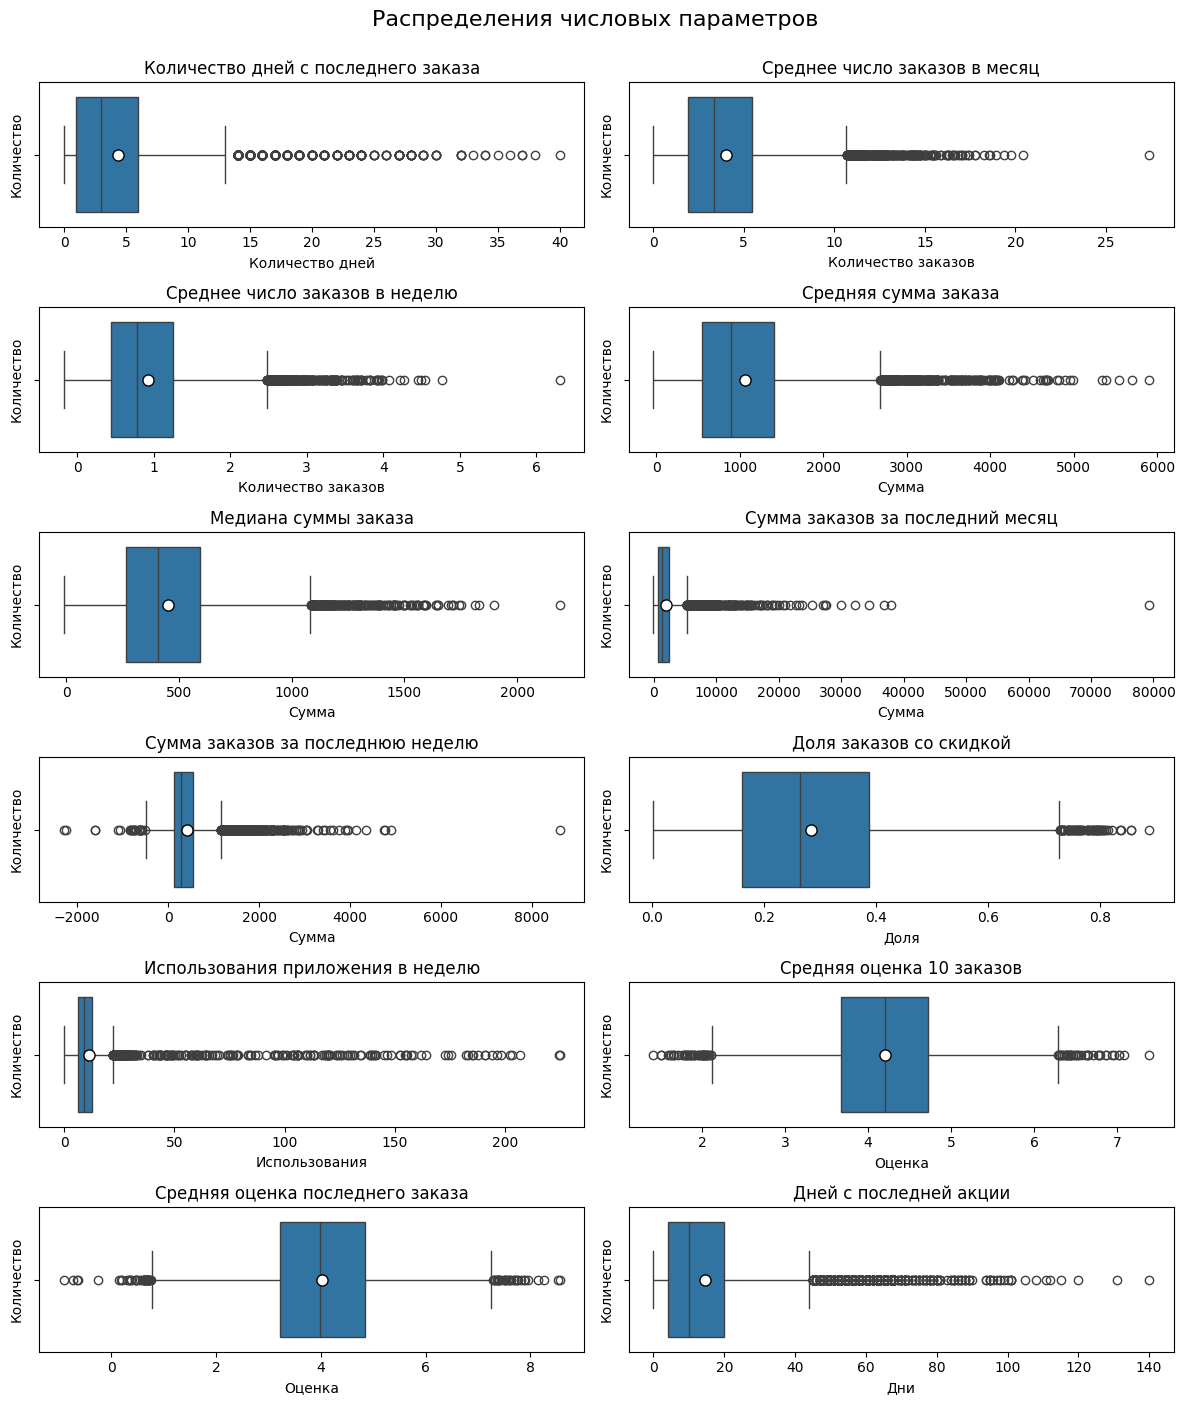

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,app_opens_per_week,review_rating_last_10,review_rating_last_1,days_since_last_promo
count,9134.000000,9454.000000,9659.000000,9476.000000,9232.000000,9748.000000,9120.000000,9653.000000,9179.000000,9362.000000,9214.000000,9338.000000
mean,4.391285,4.025081,0.929998,1063.254822,452.643042,1945.439275,412.764040,0.283965,11.327660,4.207272,4.022551,14.562969
std,4.853955,2.830559,0.657909,707.615045,258.899193,2375.596627,446.166446,0.158722,14.512342,0.782584,1.205782,15.308919
min,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559468,0.002162,0.000000,1.415526,-0.897000,0.000000
25%,1.000000,1.931762,0.445322,552.806327,263.584473,628.239460,136.251186,0.159470,6.335269,3.675187,3.217563,4.000000
50%,3.000000,3.378246,0.783019,898.368853,405.841711,1294.345827,287.099474,0.263945,9.214974,4.205958,3.989637,10.000000
75%,6.000000,5.434299,1.258550,1405.845229,591.515371,2475.248185,549.310546,0.386869,12.715057,4.718466,4.844709,20.000000
90%,11.000000,7.840757,1.819675,1984.705468,801.797257,4150.845846,929.006810,0.505413,17.033734,5.212671,5.596354,34.000000
95%,14.000000,9.599385,2.210392,2415.455471,933.286735,5757.687254,1228.738211,0.581697,20.709637,5.514591,6.002330,46.000000
99%,22.000000,13.218355,3.038125,3459.507742,1266.532849,10160.726030,2055.538920,0.702913,83.536390,6.039827,6.818351,69.000000


In [10]:
num_columns = [
    'days_since_last_order',
    'order_frequency_month',
    'order_frequency_week',
    'avg_order_value',
    'median_order_value',
    'total_spent_last_month',
    'total_spent_last_week',
    'discount_usage_rate',
    'app_opens_per_week',
    'review_rating_last_10',
    'review_rating_last_1',
    'days_since_last_promo'   
]

bool_columns = [
    'seasonal_menu_tried',
    'notifications_enabled',
    'coffee_preference_change'
]

def build_distributions():
    graph_data = [
    [df, 'days_since_last_order', "Количество дней с последнего заказа", "Количество дней", "Количество"],
    [df, 'order_frequency_month', "Среднее число заказов в месяц", "Количество заказов", "Количество"],
    [df, 'order_frequency_week', "Среднее число заказов в неделю", "Количество заказов", "Количество"],
    [df, 'avg_order_value', "Средняя сумма заказа", "Сумма", "Количество"],
    [df, 'median_order_value', "Медиана суммы заказа", "Сумма", "Количество"],
    [df, 'total_spent_last_month', "Сумма заказов за последний месяц", "Сумма", "Количество"],
    [df, 'total_spent_last_week', "Сумма заказов за последнюю неделю", "Сумма", "Количество"],
    [df, 'discount_usage_rate', "Доля заказов со скидкой", "Доля", "Количество"],
    [df, 'app_opens_per_week', "Использования приложения в неделю", "Использования", "Количество"],
    [df, 'review_rating_last_10', "Средняя оценка 10 заказов", "Оценка", "Количество"],
    [df, 'review_rating_last_1', "Средняя оценка последнего заказа", "Оценка", "Количество"],
    [df, 'days_since_last_promo', "Дней с последней акции", "Дни", "Количество"]]
    
    fig, axes = plt.subplots(6, 2, figsize=(12, 18))

    for ax, args in zip(axes.flatten(), graph_data):
        draw_histogram_grid(*args, **{'hue': 'churn', 'kde': True, 'ax': ax})

    plt.suptitle("Распределения числовых параметров", fontsize=16, y=1)
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(6, 2, figsize=(12, 14))

    for ax, args in zip(axes.flatten(), graph_data):
        draw_boxplot_grid(*args, **{'ax': ax})

    plt.suptitle("Распределения числовых параметров", fontsize=16, y=1)
    plt.tight_layout()
    plt.show()

build_distributions()

df[num_columns].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.995])

- В суммах заказов (средняя, медианная, сумма за месяц и за неделю)наблюдаются отрицательные значения и выбросы почти до 80000р. Отрицательные значения могут относиться к отмененным заказам - такие заказы вычитаются при расчете частоты, так же вычитаются суммы при расчете агрегатных показателей. В этом случае отрицательные значения нельзя удалять или исправлять, потому что в этом случае будет нарушена логика расчета частоты и агрегатных сумм заказов.
- Все распределения близки к нормальному. Для оценок распределение симметричное, для остальных признаков - с тяжелыми правыми хвостами. 
- Суммы заказов за неделю имеют выбросы в отрицательную область, что, вероятно, говорит о значительном количестве отмененных заказов.
- Наиболее значительные выбросы наблюдаются в столбце `total_spent_last_month`. Можно удалить строки по 99.9 процентилю или заменить этот признак на его логарифм.
- Пропуски в непрерывных признаках предлагается заполнить медианой, а в категориальных - модой.

Строк к удалению по 99.9 процентилю во всем датасете: 10 (0.10%)


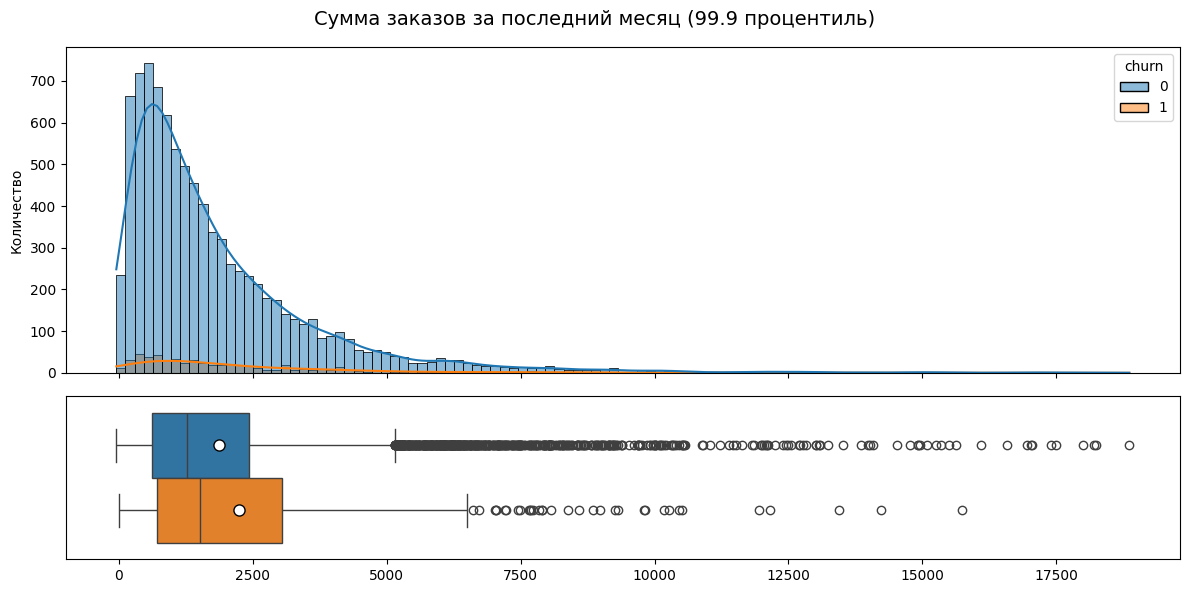

In [32]:
# Удалим выбросы в столбце total_spent_last_month по 99.9 процентилю
last_count = len(df)
percentile_999 = df['total_spent_last_month'].quantile(0.999)
new_count = last_count - (df['total_spent_last_month'] < percentile_999).sum()

print(f"Строк к удалению по 99.9 процентилю во всем датасете: {new_count} ({new_count / initial_count * 100:.2f}%)")

df_filtered = df[df['total_spent_last_month'] < percentile_999]

# Построим диаграмму распределения оставшихся данных
draw_double_diag(df_filtered, 
                    "Сумма заказов за последний месяц (99.9 процентиль)", 
                    'total_spent_last_month',
                    'churn',
                    "Сумма",
                    "Количество")
df = df_filtered
last_count = len(df)

- Исследуем корреляцию признаков между собой. Построим матрицу корреляций:

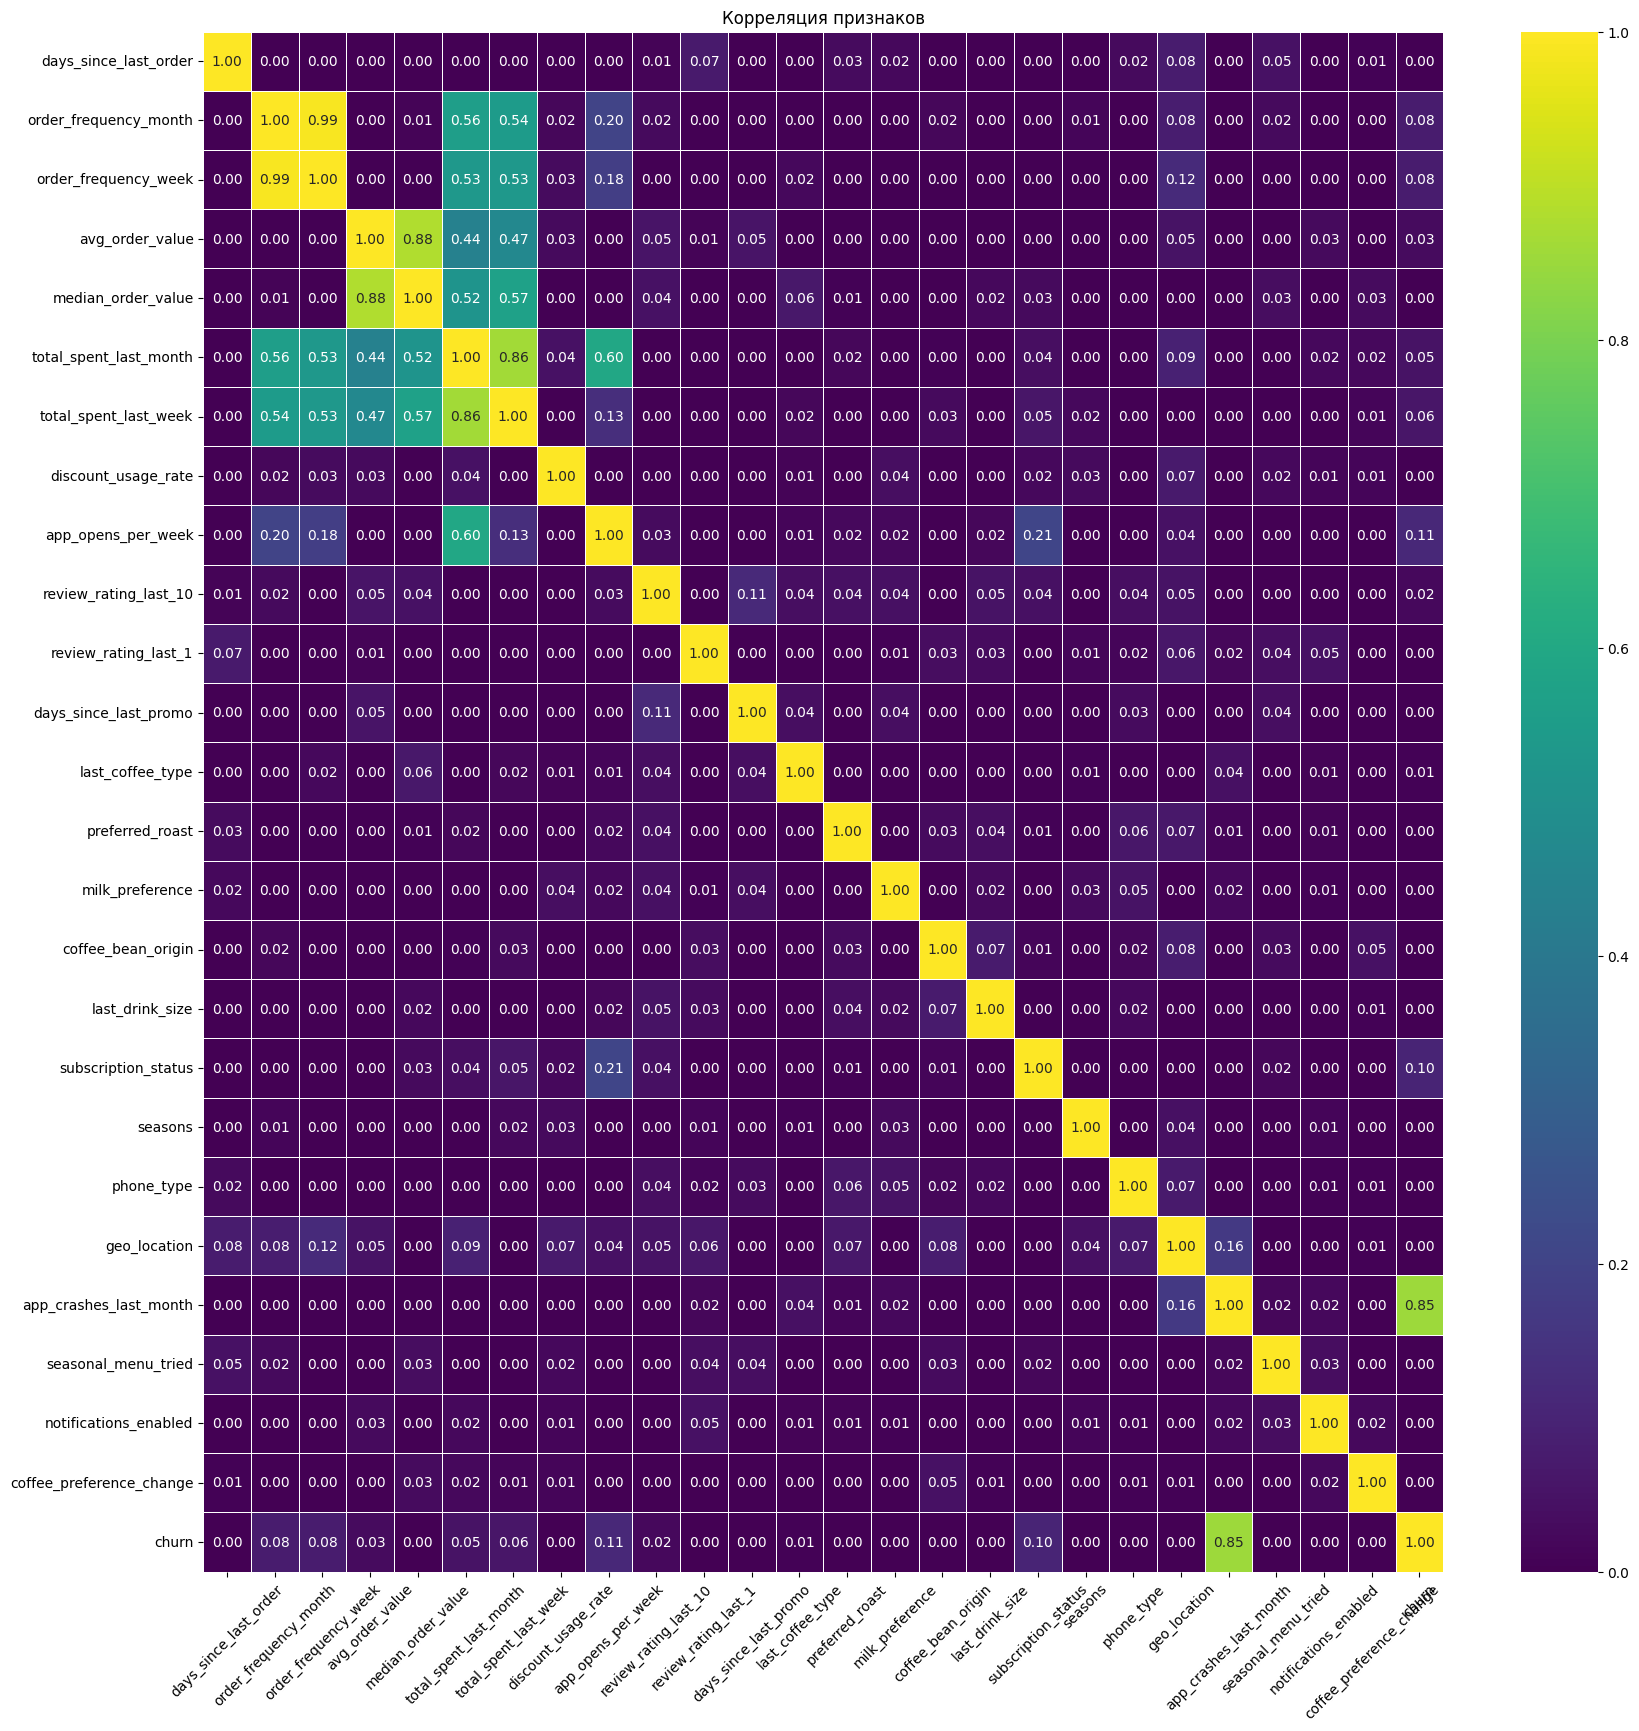

In [12]:
phik_matrix = phik.phik_matrix(df[num_columns + cat_columns + bool_columns + ['churn']], 
                               interval_cols=num_columns)
draw_heatmap(phik_matrix, "Корреляция признаков", figsize=(20, 20))

- Наибольшая корреляция наблюдается у схожих признаков - частоты заказов в месяц с частотой за неделю и у медианной стоимости со средней стоимостью заказа. Из этих двух пар для обучения модели можно оставить по одному признаку, например, `avg_order_value` и `order_frequency_month`.
- Средняя корреляция у расходов за последний месяц и последнюю неделю друг с другом и со средним количеством заказов в месяц и в неделю.
- Интересна корреляция суммарных расходов за месяц с количеством запусков приложения в неделю. Можно попробовать заменить признак `app_opens_per_week` на отношение $\frac{total\_spent\_last\_month}{app\_opens\_per\_week}$
- Наблюдается высокая корреляция оттока клиентов с количество сбоев в приложении. Вероятно, `app_crashes_last_month` будет самым важным признаком для прогнозирования оттока.
- Признаки `seasonal_menu_tried`, `notifications_enabled`, `coffee_preference_change`, содержащие логические значения (0/1) не коррелируют с целевой переменной, их можно убрать.

#### Выводы:
- В датасете были найдены дубликаты в количестве 414 (3.96%). Они были удалены.
- Целевой переменной датасета является переменная `churn`, содержащая метку класса (0/1). Соотношение положительного и отрицательного классов 6% против 94%.
- Доля уходящих пользователей в наибольшей степени связана со статусом подписки. Чаще всего уходят пользователи с подписками pro и premium. Вероятно, это связано с недостаточно высоким качеством кофе премиальных категорий или с отсутствием выгодных предложений для этой категории.
- Есть связь доли уходящих пользователей с типом приложения (пользователи на Android уходят чаще), сортом (заказавшие сорт robusta в последнем заказе), слабее связь с типом молока (almond и whole) и страной происхождения (Бразилия, Колумбия и Гватемала). Также чаще клиенты уходят весной.
- Зависимость ухода клиента от количества сбоев приложения очень высока - уходят практически все клиенты, у которых за месяц было 4 и более сбоев. Можно предположить, что одна из причин ухода - низкое качество приложения на Android.
- Признаки с небольщим количество значений могут быть закодированы с использованием метода One-hot Encoding. Это относится к признакам `subscription_status`, `last_coffee_type`, `phone_type`, `seasons`, `milk_preference`.
- Признак `geo_location` содержит большое количество значений, поэтому его следует закодировать при помощи Tagret Encoding.
- Суммы заказов за неделю имеют выбросы в отрицательную область, что, вероятно, говорит о значительном количестве отмененных заказов.
- Выбросы в столбце `total_spent_last_month` будут влиять на положение разделяющей классы гиперплоскости, сдвигая ее в сторону аномально больших значений и вызывая переобучение, поэтому было решено их удалить по 99.9 процентилю. Количество удаленных строк - 298 (2.85% от исходного датасета).
- Пропуски в непрерывных признаках предлагается заменить на медиану.
- Наибольшая корреляция наблюдается у схожих признаков - частоты заказов в месяц с частотой за неделю и у медианной стоимости со средней стоимостью заказа. Из этих двух пар для обучения модели можно оставить по одному признаку, например, `avg_order_value` и `order_frequency_week`
- Присутствует корреляция суммарных расходов за месяц с количеством запусков приложения в неделю. Можно попробовать заменить признак `app_opens_per_week` на отношение $\frac{total\_spent\_last\_month}{app\_opens\_per\_week}$
- Признаки `seasonal_menu_tried`, `notifications_enabled`, `coffee_preference_change`, содержащие логические значения (0/1) не коррелируют с целевой переменной, их можно убрать.

## Этап 3. Предобработка данных


- Разделим данные на обучающие/валидационные и тестовые в отношении 4:1:

In [13]:
# Столбцы с признаками
cat_columns = [
               'last_coffee_type', 
               'preferred_roast',
               'milk_preference',
               'coffee_bean_origin',
               'last_drink_size',
               'subscription_status',
               'seasons',
               'phone_type',
               'geo_location']

num_columns = [
    'days_since_last_order',
    'order_frequency_month',
    'order_frequency_week',
    'avg_order_value',
    'median_order_value',
    'total_spent_last_month',
    'total_spent_last_week',
    'discount_usage_rate',
    'app_opens_per_week',
    'review_rating_last_10',
    'review_rating_last_1',
    'days_since_last_promo',
    'app_crashes_last_month' 
]

bool_columns = [
    'seasonal_menu_tried',
    'notifications_enabled',
    'coffee_preference_change'
]

feature_num_cols = num_columns.copy()
feature_cat_cols = cat_columns.copy()
feature_bool_cols = bool_columns.copy()

feature_cols = feature_num_cols + feature_cat_cols + bool_columns

print("Признаки для обучения:\n\n" + '\n'.join(feature_cols))

X = df[feature_cols].copy()
y = df['churn']

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"\nРазмер обучающей выборки: {len(X_train_val)}, тестовой: {len(X_test)}.")

Признаки для обучения:

days_since_last_order
order_frequency_month
order_frequency_week
avg_order_value
median_order_value
total_spent_last_month
total_spent_last_week
discount_usage_rate
app_opens_per_week
review_rating_last_10
review_rating_last_1
days_since_last_promo
app_crashes_last_month
last_coffee_type
preferred_roast
milk_preference
coffee_bean_origin
last_drink_size
subscription_status
seasons
phone_type
geo_location
seasonal_menu_tried
notifications_enabled
coffee_preference_change

Размер обучающей выборки: 7790, тестовой: 1948.


- Создадим пайплайн для базовой модели логистической регрессии:
    1. Заполнение пропусков в категориальных столбцах модой.
    2. Заполнение пропусков в логических столбцах значением 0 (False).
    3. Кодирование при помощи One-hot категориальных признаков (кроме `geo_location`).
    4. Кодирование при помощи TargetEncoding признака `geo_location`.
    5. Заполнение пропусков в числовых столбцах медианой.
    6. Масштабирование числовых признаков.
    7. Обучение модели.

Базовая модель будет использовать полный набор признаков из исходного датасета.

In [14]:
# Признаки для One-hot encoding
ohe_cols = list(set(cat_columns) - {'geo_location'})

# Признаки для Target Encoding
target_enc_cols = ['geo_location']

def create_pipeline(feature_num_cols, ohe_cols, target_enc_cols, feature_bool_cols, feature_engineering, classifier):
    # Пайплайн обработки OHE-признаков
    cat_ohe_pipeline = Pipeline([
        ('fill_mode', SimpleImputer(strategy='most_frequent')),
        ('ohe_encode',  OneHotEncoder())
    ])

    # Пайплайн обработки признаков Target Encoding
    cat_target_pipeline = Pipeline([
        ('fill_mode', SimpleImputer(strategy='most_frequent')),
        ('target_encode', TargetEncoder(random_state=RANDOM_STATE))
    ])

    # Пайплайн обработки числовых признаков
    num_pipeline = Pipeline([
        ('fill_median', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ])

    # Пайплайн обработки логических признаков
    bool_pipeline = Pipeline([
        ('fill_mode', SimpleImputer(strategy='constant', fill_value=0.0))
    ])

    # Собранный препроцессинг
    preprocess_ct = ColumnTransformer([
        ('cat_ohe', cat_ohe_pipeline, ohe_cols),
        ('cat_target', cat_target_pipeline, target_enc_cols),
        ('num', num_pipeline, feature_num_cols),
        ('bool', bool_pipeline, feature_bool_cols)
    ])

    return Pipeline([
        ('feature_eng', FunctionTransformer(feature_engineering, validate=False)),
        ('preprocess', preprocess_ct),
        ('classify', classifier)
    ])

lr = LogisticRegression(random_state=RANDOM_STATE)

# Пайплайн для логистической регрессии с предобработкой
lr_pipeline = create_pipeline(feature_num_cols, 
                              ohe_cols, 
                              target_enc_cols, 
                              feature_bool_cols, 
                              lambda X: X, 
                              lr)

# Пайплайн для DummyRegressor с предобработкой
dc_pipeline = create_pipeline(feature_num_cols, 
                              ohe_cols, 
                              target_enc_cols, 
                              feature_bool_cols, 
                              lambda X: X, 
                              DummyClassifier(strategy='prior'))

display(lr_pipeline)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_eng', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function <la...0024A8C811380>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments

## Этап 4. Обучение модели

- Проведем кросс-валидацию для пайплайнов `DummyClassifier` и логистической регрессии:

In [15]:
# Подготавливаем кросс-валидацию
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Проведем кросс-валидацию DummyClassifier
metrics_dc = cross_validate(
    estimator=dc_pipeline,           
    X=X_train_val,
    y=y_train_val,
    scoring=['accuracy', 'f1', 'average_precision', 'precision', 'recall', 'neg_log_loss'],
    cv=cv,
    return_train_score = True,
    return_estimator = True,
    n_jobs=-1
)

# Проведем кросс-валидацию логистической регрессии
metrics_lr = cross_validate(
    estimator=lr_pipeline,           
    X=X_train_val,
    y=y_train_val,
    scoring=['accuracy', 'f1', 'average_precision', 'precision', 'recall', 'neg_log_loss'],
    cv=cv,
    return_train_score = True,
    return_estimator = True,
    n_jobs=-1
)

# Посчитаем и выведем средние значения метрик по фолдам
display(pd.DataFrame({
    'LogisticRegression': pd.DataFrame(metrics_lr).iloc[:, 3:].mean(), 
    'DummyClassifier': pd.DataFrame(metrics_dc).iloc[:, 3:].mean()}).style.background_gradient(cmap='viridis'))

,LogisticRegression,DummyClassifier
test_accuracy,0.958023,0.940436
train_accuracy,0.960013,0.940436
test_f1,0.549937,0.000000
train_f1,0.567662,0.000000
test_average_precision,0.659283,0.059564
train_average_precision,0.685203,0.059564
test_precision,0.760288,0.000000
train_precision,0.797354,0.000000
test_recall,0.431136,0.000000
train_recall,0.440740,0.000000


#### Выводы:
- Модель логистической регрессии на необработанных признаках показывает результаты примерно в 11 раз лучшие, чем `DummyClassifier` по основной метрике `PR-AUC`. Это хороший результат для данных с сильным дисбалансом классов, указывающий на то, что обучение модели прошло успешно.
- Метрика `accuracy` для представленных данных не имеет смысла, так как из-за дисбаланса классов по ней нельзя определить, правильно ли модель определяет именно положительный класс. Разница с `DummyRegressor` по этой метрике минимальна.
- Значение метрики `precision` 0.76 показывает, что 76% клиентов, определенных моделью как уходящие, были классифицированы правильно. Однако из всех уходящих клиентов модель, согласно метрике `recall`, определяет только 43.1. Учитывая требования к точности модели, порог определения вероятности ухода нужно поднять.

## Этап 5. Создание новых признаков

- Вместо сильно коррелирующих признаков `total_spent_last_month` и `app_opens_per_week` добавим их отношение.
- Удалим признаки `order_frequency_week` и `median_order_value`, которые сильно коррелируют с похожими признаками `order_frequency_month` и `avg_order_value`.
- Рост признака `app_crashes_last_month` сильно влияет на целевую переменную. Возведем его в квадрат, чтобы указать модели на эту зависимость.
- Распределение признаков `app_opens_per_week` и `total_spent_last_month` сильно скошено - заменим первый признак квадратным корнем, а второй - логарифмом.
- Удалим категориальный признак `preferred_roast`, который не связан с долей уходящих пользователей.
- Удалим логические признаки, не коррелирующие с целевой переменной.

In [16]:
# Формируем список признаков для усовершенствованной модели
enh_feature_num_cols = num_columns.copy()
enh_feature_num_cols.remove('median_order_value')
enh_feature_num_cols.remove('order_frequency_week')
enh_feature_num_cols.remove('app_opens_per_week')
enh_feature_num_cols.remove('total_spent_last_month')
enh_feature_num_cols.remove('app_crashes_last_month')

enh_feature_num_cols.append('spent_app_open_ratio')
enh_feature_num_cols.append('app_crashes_last_month_2')
enh_feature_num_cols.append('app_opens_per_week_sqrt')
enh_feature_num_cols.append('total_spent_last_month_log')

enh_feature_cat_cols = cat_columns.copy()
enh_feature_cat_cols.remove('preferred_roast')

enh_feature_bool_cols = []

# Признаки для One-hot encoding
enh_ohe_cols = list(set(enh_feature_cat_cols) - {'geo_location'})

# Признаки для Target Encoding
enh_target_enc_cols = ['geo_location']

def transform_features(X):
    X_new = pd.DataFrame(X, columns=feature_cols)
    X_new['spent_app_open_ratio'] = X_new['total_spent_last_month'] / (1 + X_new['app_opens_per_week'])
    X_new['app_crashes_last_month_2'] = X_new['app_crashes_last_month'] ** 2
    X_new['app_opens_per_week_sqrt'] = np.sqrt(X_new['app_opens_per_week'])
    
    # Прибавляем минимум, так как в поле есть отрицательные значения
    X_new['total_spent_last_month_log'] = np.log1p(X_new['total_spent_last_month'] + 
                                                   np.abs(X_new['total_spent_last_month'].min()))
    return X_new

lr_enh_pipeline = create_pipeline(enh_feature_num_cols, 
                                  enh_ohe_cols, 
                                  enh_target_enc_cols, 
                                  enh_feature_bool_cols, 
                                  transform_features, 
                                  LogisticRegression(random_state=RANDOM_STATE))

# Проведем кросс-валидацию усовершенствованного пайплайна логистической регрессии
metrics_lr_enh = cross_validate(
    estimator=lr_enh_pipeline,           
    X=X_train_val,
    y=y_train_val,
    scoring=['accuracy', 'f1', 'average_precision', 'precision', 'recall', 'neg_log_loss'],
    cv=cv,
    return_train_score = True,
    return_estimator = True,
    n_jobs=-1
)

# Посчитаем и выведем средние значения метрик по фолдам
display((pd.DataFrame({
                        'LogisticRegression': pd.DataFrame(metrics_lr).iloc[:, 3:].mean(), 
                        'Enhanced LogReg': pd.DataFrame(metrics_lr_enh).iloc[:, 3:].mean()
                    })
        .style
        .background_gradient(cmap='viridis')))

,LogisticRegression,Enhanced LogReg
test_accuracy,0.958023,0.959692
train_accuracy,0.960013,0.961682
test_f1,0.549937,0.579053
train_f1,0.567662,0.597070
test_average_precision,0.659283,0.686017
train_average_precision,0.685203,0.703638
test_precision,0.760288,0.766419
train_precision,0.797354,0.798682
test_recall,0.431136,0.465615
train_recall,0.440740,0.476844


- Модель с новым набором признаков показывает лучшие метрики: увеличились `F1`, `PR-AUC`, `accuracy`, `precision`, `recall`, уменьшился `log_loss`. Важное улучшение состоит в том, что не увеличился разрыв между средними значениями метрик по фолдам на тренировочной и тестовой выборках. Это значит, что модель не стала больше переобучаться.
- Несмотря на улучшение метрики `recall`, ее значение все равно составляет около 46.5%, т.е. из всех уходящих пользователей модель определяет менее половины.

- Изучим коэффициенты признаков, чтобы определить наиболее важные из них:

In [17]:
lr_enh_pipeline.fit(X_train_val, y_train_val)
coef = lr_enh_pipeline['classify'].coef_
named_coef = pd.Series(np.abs(coef[0]), 
          index=lr_enh_pipeline['preprocess'].get_feature_names_out())
display((pd.DataFrame(named_coef.sort_values(ascending=False))
         .style
         .background_gradient(cmap='viridis')))

,0
num__app_crashes_last_month_2,1.754095
num__spent_app_open_ratio,0.667027
cat_ohe__subscription_status_pro,0.621738
num__order_frequency_month,0.487587
cat_ohe__milk_preference_none,0.395992
cat_ohe__subscription_status_basic,0.392876
num__total_spent_last_week,0.290841
cat_ohe__subscription_status_none,0.280819
num__app_opens_per_week_sqrt,0.277064
cat_ohe__phone_type_web,0.247058


- Как и предполагалось, самым важным признаком является количество сбоев приложения. Вторым по важности оказался добавленный признак `spent_app_open_ratio` - решение о его добавлении оказалось верным.
- Оставим набор признаков без изменений.

## Этап 6. Эксперименты с гиперпараметрами

- Попробуем улучшить метрики модели при помощи подбора гиперпараметров. 
- Будем менять следующие гиперпараметры:

    1. Порог положительного класса.
    2. Коэффициент регуляризации $C$.
- Кросс-валидацию будем проводить в цикле, чтобы вручную менять порог положительного класса.

In [18]:
# Функция для расчета метрик
def calc_metrics(y, y_pred_proba, threshold=0.5, prefix='train_'):
    y_pred = (y_pred_proba >= threshold)
    return {(prefix + 'accuracy'): accuracy_score(y, y_pred),
            (prefix + 'f1'): f1_score(y, y_pred),
            (prefix + 'average_precision'): average_precision_score(y, y_pred_proba),
            (prefix + 'precision'): precision_score(y, y_pred, zero_division=0),
            (prefix + 'recall'): recall_score(y, y_pred),
            (prefix + 'neg_log_loss'): -log_loss(y, y_pred_proba)}

# Инициализация списков гиперпараметров
thresholds = [i / 10 for i in range(3, 8)]
Cs = [10 ** i for i in range(-3, 3)]
# penalties = ['l1', 'l2', 'elasticnet']
# class_weights = [None, 'balanced', {0: 1, 1: 16.67}]

# Функция для получения оценок кросс-валидации модели с заданным значением порога
# с использованием усовершенствованного пайплайна
def cross_validate_model(label, model, threshold):
    rv = []
    pipeline = create_pipeline(enh_feature_num_cols, 
                enh_ohe_cols, 
                enh_target_enc_cols, 
                enh_feature_bool_cols, 
                transform_features, 
                model)

    for train_idx, test_idx in cv.split(X_train_val, y_train_val):
        X_train = X_train_val.iloc[train_idx]
        X_test = X_train_val.iloc[test_idx]
        y_train = y_train_val.iloc[train_idx]
        y_test = y_train_val.iloc[test_idx]
        pipeline.fit(X_train, y_train)
        train_proba = pipeline.predict_proba(X_train)[:, 1]
        test_proba = pipeline.predict_proba(X_test)[:, 1]
        cols = calc_metrics(y_train, train_proba, threshold=threshold)
        cols.update(calc_metrics(y_test, test_proba, threshold=threshold, prefix="test_"))
        rv.append(pd.Series(cols))
    
    rv_df = pd.DataFrame(rv).mean()
    rv_df['model'] = label
    return rv_df

# Вычислим метрики для всех моделей и скомбинируем их в один датафрейм
metrics = []
for t in thresholds:
    for c in Cs:
        model = LogisticRegression(C=c, random_state=RANDOM_STATE)
        label = f"t={t}, C={c}"
        print("Обрабатыватся модель:", label)
        metrics.append(cross_validate_model(label, model, t))
metrics_df = pd.DataFrame(metrics)
metrics_df.set_index('model', inplace=True)


Обрабатыватся модель: t=0.3, C=0.001
Обрабатыватся модель: t=0.3, C=0.01
Обрабатыватся модель: t=0.3, C=0.1
Обрабатыватся модель: t=0.3, C=1
Обрабатыватся модель: t=0.3, C=10
Обрабатыватся модель: t=0.3, C=100
Обрабатыватся модель: t=0.4, C=0.001
Обрабатыватся модель: t=0.4, C=0.01
Обрабатыватся модель: t=0.4, C=0.1
Обрабатыватся модель: t=0.4, C=1
Обрабатыватся модель: t=0.4, C=10
Обрабатыватся модель: t=0.4, C=100
Обрабатыватся модель: t=0.5, C=0.001
Обрабатыватся модель: t=0.5, C=0.01
Обрабатыватся модель: t=0.5, C=0.1
Обрабатыватся модель: t=0.5, C=1
Обрабатыватся модель: t=0.5, C=10
Обрабатыватся модель: t=0.5, C=100
Обрабатыватся модель: t=0.6, C=0.001
Обрабатыватся модель: t=0.6, C=0.01
Обрабатыватся модель: t=0.6, C=0.1
Обрабатыватся модель: t=0.6, C=1
Обрабатыватся модель: t=0.6, C=10
Обрабатыватся модель: t=0.6, C=100
Обрабатыватся модель: t=0.7, C=0.001
Обрабатыватся модель: t=0.7, C=0.01
Обрабатыватся модель: t=0.7, C=0.1
Обрабатыватся модель: t=0.7, C=1
Обрабатыватся модел

- Выведем метрики, отсортированные по `PR-AUC`, `F1` и `precision`:

In [19]:
display((metrics_df
         .sort_values(by=['test_average_precision', 
                                    'test_f1', 
                                    'test_precision'], 
                               ascending=False)
          .style
          .background_gradient(cmap='viridis')))

,train_accuracy,train_f1,train_average_precision,train_precision,train_recall,train_neg_log_loss,test_accuracy,test_f1,test_average_precision,test_precision,test_recall,test_neg_log_loss
model,,,,,,,,,,,,
"t=0.3, C=0.1",0.955712,0.635197,0.703385,0.623469,0.647639,-0.112017,0.955584,0.633785,0.687987,0.623891,0.644437,-0.116139
"t=0.4, C=0.1",0.961136,0.627270,0.703385,0.731081,0.549587,-0.112017,0.959692,0.613990,0.687987,0.715247,0.538943,-0.116139
"t=0.5, C=0.1",0.961489,0.582918,0.703385,0.820920,0.452062,-0.112017,0.959178,0.560516,0.687987,0.780969,0.437634,-0.116139
"t=0.6, C=0.1",0.960045,0.526065,0.703385,0.896564,0.372310,-0.112017,0.958280,0.503562,0.687987,0.868696,0.355540,-0.116139
"t=0.7, C=0.1",0.958761,0.482461,0.703385,0.955428,0.322733,-0.112017,0.958537,0.478005,0.687987,0.955528,0.318934,-0.116139
"t=0.3, C=0.01",0.960205,0.628673,0.696383,0.707458,0.566291,-0.119302,0.959050,0.619582,0.687259,0.694297,0.560425,-0.121241
"t=0.4, C=0.01",0.959820,0.540013,0.696383,0.848817,0.396018,-0.119302,0.958408,0.523617,0.687259,0.824675,0.383661,-0.121241
"t=0.5, C=0.01",0.958151,0.475448,0.696383,0.938343,0.318424,-0.119302,0.957766,0.468417,0.687259,0.936886,0.312482,-0.121241
"t=0.6, C=0.01",0.957028,0.443688,0.696383,0.969070,0.287714,-0.119302,0.956611,0.438273,0.687259,0.956044,0.284502,-0.121241


- Метрики `PR-AUC` очень слабо зависят от гиперпараметров. При выборе модели можно опираться на `precision`, `recall` и `f1`.
- В качестве финальной модели предлагается взять логистическую регрессию с параметром $C=0.1$ и порогом $t=0.7$. Она определила в среднем 31.9% из уходящих клиентов (метрика `recall`) и правильно определила уход клиента в 95.5% случаев (метрика `precision`).

## Этап 7. Подготовка финальной модели

- Обучим пайплайн с выбранными гиперпараметрами на объединенной обучающей и валидационной выборке:

In [30]:
C = 0.1
t = 0.7

final_pipeline = create_pipeline(enh_feature_num_cols,
                enh_ohe_cols, 
                enh_target_enc_cols, 
                enh_feature_bool_cols, 
                transform_features,
                LogisticRegression(C=C, random_state=RANDOM_STATE))

final_pipeline.fit(X_train_val, y_train_val)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_eng', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function tra...0024A8C813270>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments

- Запустим пайплайн на обучающей и отложенной тестовой выборках:

In [31]:
# Получаем вероятности на обучающей и тестовой выборках
y_train_pred_proba = final_pipeline.predict_proba(X_train_val)
y_test_pred_proba = final_pipeline.predict_proba(X_test)

# Сравним метрики выбранной модели на обучающей и тестовой выборках
cols = calc_metrics(y_train_val, y_train_pred_proba[:, 1], threshold=t)
cols.update(calc_metrics(y_test, y_test_pred_proba[:, 1], threshold=t, prefix="test_"))
final_metrics = pd.DataFrame({"Train": metrics_df.loc["t=0.7, C=0.1"],
                              "Test": pd.Series(cols)})
display(final_metrics)

,Train,Test
train_accuracy,0.958761,0.958537
train_f1,0.482461,0.478191
train_average_precision,0.703385,0.701518
train_precision,0.955428,0.954839
train_recall,0.322733,0.318966
train_neg_log_loss,-0.112017,-0.112359
test_accuracy,0.958537,0.962012
test_f1,0.478005,0.559524
test_average_precision,0.687987,0.751691
test_precision,0.955528,0.903846


#### Выводы:
- На тестовой выборке метрики `F1`, `PR-AUC`, `recall` оказались лучше, чем на обучающей; оценка `precision` - хуже.
- На новых данных модель определяет 40.5% уходящих клиентов и правильно определяет уход клиента в 90.4% случаев. Баланс между полнотой и точностью сдвинут в сторону точности, как и требовалось в исходных условиях.

## Этап 8. Отчёт о проделанной работе

- Для решения задачи классификации пользователей был предоставлен датасет в формате CSV-файла, содержащий агрегированные показатели по пользователям и целевую переменную.
- В процессе исследовательского анализа данных были изучены распределения категориальных и числовых признаков, их корреляция друг с другом и с целевой переменной.
- Для решения задачи прогноза оттока клиентов был создан пайплайн, состоящий из двух этапов: предобработки данных и логистической регрессии. 
- Пайплайн был обучен на полном наборе признаков, после чего было выполнено его сравнение с пайплайном на основе простой статистической модели. 
- Пайплайн на основе логистической регрессии показал значительно лучшее качество, чем простая статистическая модель (оценка по метрике `PR-AUC` лучше в 11 раз).
- На основании результатов исследовательского анализа данных было решено изменить набор признаков. Обученная на новом наборе признаков модель показала лучшие результаты по всем метрикам и меньшую переобученность, чем исходная. Признаки, введенные в результате преобразований, получили после обучения наибольшие коэффициенты - это подтверждает правильность проведенных преобразований.
- Усовершенствованный пайплайн был протестирован с разными наборами гиперпараметров (коэффициент регуляризации $C$ и порог вероятности положительного класса $t$). В соответсвии с требованием повышения точности определения положительного класса была выбрана модель с коэффициентом регуляризации $C=0.1$ и порогом $t=0.7$. На тестовых данных модель определила 40.5% уходящих клиентов и правильно определила уход клиента в 90.4% случаев. Повышенный порог обеспечил сдвиг характеристик модели в сторону большей точности в ущерб полноте, а усиливающий регуляризацию коэффициент способствует меньшему переобучению.

## Этап 9. Сохранение модели для продакшена

- Сохраним обученный пайплайн для внедрения:

In [22]:
FILE_NAME = "churn_predict.joblib"

# Сохраняем пайплайн на диск
joblib.dump(final_pipeline, FILE_NAME)

# Проверка
load_pipeline = joblib.load(FILE_NAME)
y_test_pred_load = load_pipeline.predict_proba(X_test)

diff = np.abs(y_test_pred_proba - y_test_pred_load).sum()
if diff == 0.0:
    print("Пайплайн сохранен, проверка прошла успешно.")
else:
    print("Ошибка: ", diff)

Пайплайн сохранен, проверка прошла успешно.


Ссылка для скачивания сохраненного пайплайна (GitHub): [churn_predict.joblib](https://github.com/tvorogov-code/ds-yandex/raw/refs/heads/main/notebooks/%D0%9F%D1%80%D0%BE%D0%B5%D0%BA%D1%82%20%D1%81%D0%BF%D1%80%D0%B8%D0%BD%D1%82%D0%B0%2011/churn_predict.joblib)